In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [16]:
tt = sns.load_dataset("titanic")

features = [ "pclass", "sex", "fare", "embarked","age",]
target = ["survived"]

# missing data


imp_median = SimpleImputer(strategy="median")
tt[["age"]] = imp_median.fit_transform(tt[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
tt[["embarked"]] = imp_freq.fit_transform(tt[["embarked"]])

# encode

le = LabelEncoder()
tt["sex"] = le.fit_transform(tt["sex"])
tt["embarked"] = le.fit_transform(tt["embarked"])

X = tt[features]
y = tt["survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# decision tree - no pruning


model = DecisionTreeClassifier(max_depth=4)
model.fit(X_train, y_train)


y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("train accuracy", accuracy_score(y_train, y_pred_train))
print("test accuracy", accuracy_score(y_test, y_pred_test))

train accuracy 0.8398876404494382
test accuracy 0.7988826815642458


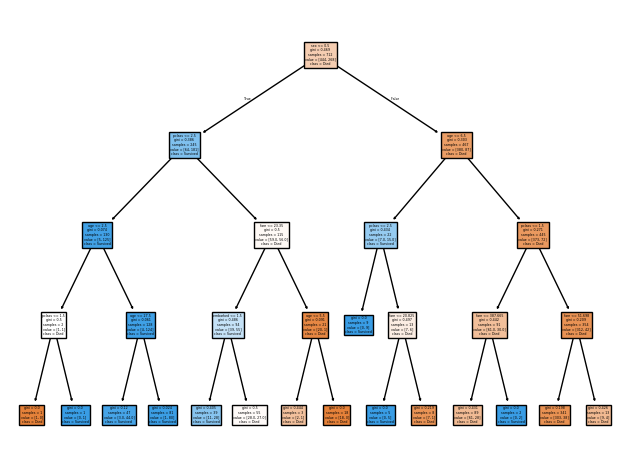

In [17]:
from sklearn.tree import plot_tree
plt.Figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True
)
plt.tight_layout()
plt.show()

In [19]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=501,
    oob_score=True,
    max_depth=4
)

rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)

print("oob score", rf.oob_score_)
print("test accuracy", accuracy_score(y_pred,y_test))

oob score 0.8230337078651685
test accuracy 0.8156424581005587


In [21]:
# Bagging Classifier
from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)
bagging.fit(X_train, y_train)


y_pred_test = bagging.predict(X_test)
y_pred_train = bagging.predict(X_train)

print("train accuracy", accuracy_score(y_train, y_pred_train))
print("test accuracy", accuracy_score(y_test, y_pred_test))

train accuracy 0.9775280898876404
test accuracy 0.7988826815642458


In [22]:
# Bagging Regressor
from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression(max_iter=1000)

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)
bagging.fit(X_train, y_train)


y_pred_test = bagging.predict(X_test)
y_pred_train = bagging.predict(X_train)

print("train accuracy", accuracy_score(y_train, y_pred_train))
print("test accuracy", accuracy_score(y_test, y_pred_test))

train accuracy 0.7949438202247191
test accuracy 0.7988826815642458
